cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
deed
NaN    965321
0.0     17428
1.0     17251
Name: count, dtype: int64

Commercial sales: 38861
After removing NaN and invalid prices: 28321
deed
0.0    14238
1.0    14083
Name: count, dtype: int64

With commercial deed: n=12322, mean=4,577,213,035, median=3,000,000,000
Without commercial deed: n=12908, mean=3,918,869,618, median=2,500,000,000

Welch t-test: t=12.035, p=2.89e-33
Mann-Whitney U: p=1.49e-44
t-test on log(price): t=9.619, p=7.28e-22
Cohen's d = 0.152


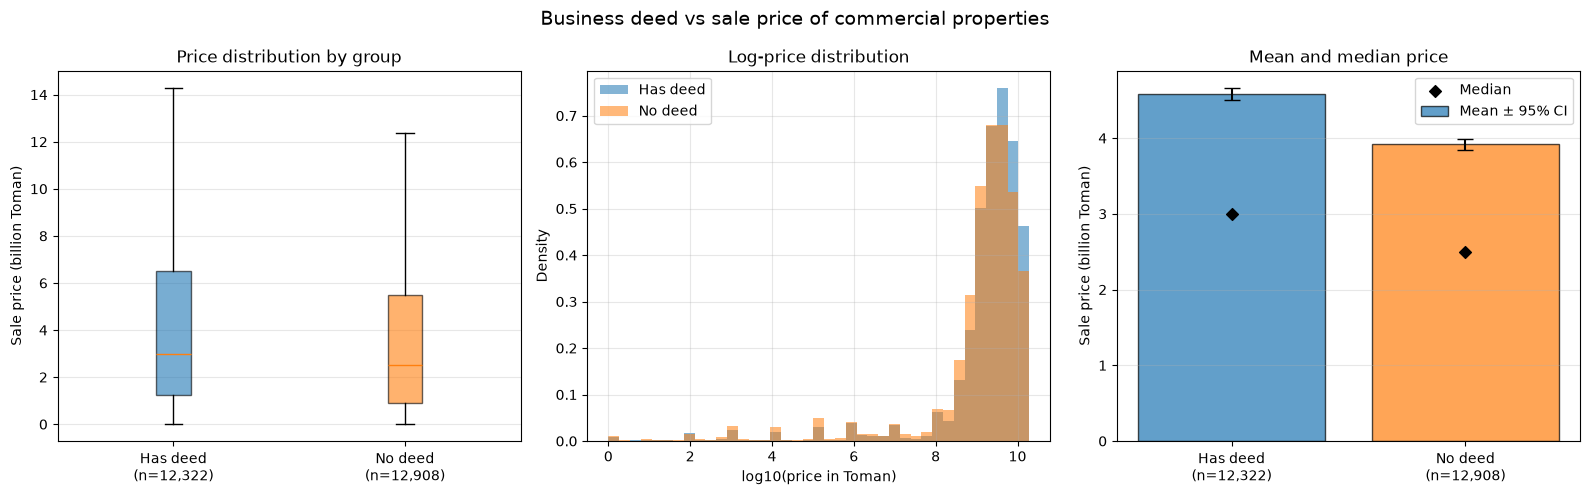

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

cols = ["cat2_slug", "cat3_slug", "price_value", "has_business_deed", "building_size"]
df = pd.read_csv(r"C:\Users\vision\Desktop\bootcamp_p1\Divar.csv", usecols=cols)

to_en = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")

def to_num(col):
    s = (col.astype(str).str.translate(to_en)
            .str.replace("٫", ".", regex=False)
            .str.replace("٬", "", regex=False)
            .str.replace(",", "", regex=False))
    return pd.to_numeric(s, errors="coerce")

df["price_value"] = to_num(df["price_value"])
df["building_size"] = to_num(df["building_size"])

b = df["has_business_deed"].astype(str).str.strip().str.lower()
df["deed"] = b.map({"true": 1, "false": 0})

print(df["cat2_slug"].value_counts())
print(df["deed"].value_counts(dropna=False))

COMMERCIAL_SELL = ["shop-sell", "office-sell", "industry-agriculture-business-sell"]
d = df[df["cat3_slug"].isin(COMMERCIAL_SELL)].copy()
print("\nCommercial sales:", len(d))
d = d.dropna(subset=["price_value", "deed"])
d = d[(d["price_value"] > 0) & (d["price_value"] <= 5e11)]
print("After removing NaN and invalid prices:", len(d))
print(d["deed"].value_counts())

q1, q3 = d["price_value"].quantile([0.25, 0.75])
iqr = q3 - q1
d = d[d["price_value"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]

yes = d.loc[d["deed"] == 1, "price_value"]
no = d.loc[d["deed"] == 0, "price_value"]
print(f"\nWith commercial deed: n={len(yes)}, mean={yes.mean():,.0f}, median={yes.median():,.0f}")
print(f"Without commercial deed: n={len(no)}, mean={no.mean():,.0f}, median={no.median():,.0f}")

t, p = stats.ttest_ind(yes, no, equal_var=False)
u, p_u = stats.mannwhitneyu(yes, no, alternative="two-sided")
lt, lp = stats.ttest_ind(np.log(yes), np.log(no), equal_var=False)
print(f"\nWelch t-test: t={t:.3f}, p={p:.3g}")
print(f"Mann-Whitney U: p={p_u:.3g}")
print(f"t-test on log(price): t={lt:.3f}, p={lp:.3g}")

sp = np.sqrt((yes.var(ddof=1) + no.var(ddof=1)) / 2)
print(f"Cohen's d = {(yes.mean() - no.mean()) / sp:.3f}")


B = 1e9  # Display price in billion Toman
labels = [f"Has deed\n(n={len(yes):,})", f"No deed\n(n={len(no):,})"]
colors = ["tab:blue", "tab:orange"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))


bp = axes[0].boxplot([yes / B, no / B], patch_artist=True, showfliers=False)
axes[0].set_xticklabels(labels)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
axes[0].set_ylabel("Sale price (billion Toman)")
axes[0].set_title("Price distribution by group")
axes[0].grid(axis="y", alpha=0.3)

# Log10 price density histogram (two groups overlaid)
lo = min(np.log10(yes).min(), np.log10(no).min())
hi = max(np.log10(yes).max(), np.log10(no).max())
bins = np.linspace(lo, hi, 40)
axes[1].hist(np.log10(yes), bins=bins, density=True, alpha=0.55, color=colors[0], label="Has deed")
axes[1].hist(np.log10(no), bins=bins, density=True, alpha=0.55, color=colors[1], label="No deed")
axes[1].set_xlabel("log10(price in Toman)")
axes[1].set_ylabel("Density")
axes[1].set_title("Log-price distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

#  Mean with 95% confidence interval + median
means = [yes.mean() / B, no.mean() / B]
ci = [1.96 * yes.sem() / B, 1.96 * no.sem() / B]
medians = [yes.median() / B, no.median() / B]
x = np.arange(2)
axes[2].bar(x, means, yerr=ci, capsize=6, color=colors, alpha=0.7, edgecolor="black", label="Mean ± 95% CI")
axes[2].scatter(x, medians, color="black", zorder=3, marker="D", label="Median")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel("Sale price (billion Toman)")
axes[2].set_title("Mean and median price")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Business deed vs sale price of commercial properties", fontsize=14)
plt.tight_layout()
plt.savefig("business_deed_price_plots.png", dpi=150)
plt.show()